# NB_NoAug_AllFeatures

**Augmentation strategy: No Augmentation (baseline)**

All other features identical across all 4 notebooks:
- Grad-CAM, t-SNE, ROC/PR curves, misclassification heatmap
- Complexity table (FLOPs, inference time, memory)
- Bootstrap confidence intervals
- Confusion matrix, per-class metrics

> Test metrics are on the held-out test set (15%, ~4,256 samples).


In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('OK')


OK


In [2]:
import os,math,random,json,warnings,zipfile,shutil,time,tracemalloc,psutil,gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import defaultdict
from itertools import cycle
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,Conv2D,MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,
    Dense,Dropout,Add,Concatenate,Multiply,Reshape,Layer
)
from tensorflow.keras.callbacks import LearningRateScheduler,EarlyStopping,ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,confusion_matrix,
    accuracy_score,precision_score,recall_score,f1_score,
    roc_curve,auc,precision_recall_curve,average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE

gpus = tf.config.list_physical_devices('GPU')
for g in gpus: tf.config.experimental.set_memory_growth(g,True)
print('TF ' + tf.__version__ + ' | GPUs: ' + str(len(gpus)))


TF 2.20.0 | GPUs: 1


In [3]:
NOTEBOOK_ID  = "NB_SoyCultivar200"
AUG_STRATEGY = "No Augmentation"
SEED=42; IMG_SIZE=(256,256); IMG_SHAPE=(256,256,3)
BATCH_SIZE=32; INITIAL_LR=1e-3; EPOCHS=60; DROPOUT_RATE=0.5
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Classes discovered dynamically in cell 3 — set placeholders here
TARGET_CLASSES = []
NUM_CLASSES    = 0
CLASS_TO_IDX   = {}
IDX_TO_CLASS   = {}
TARGET_COUNTS  = {}

KAGGLE_DATASETS = [
    ('dileshbisen123/plant-disease-dataset', 'plant-disease-dataset'),
]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

BASE_DIR    = os.path.join(os.path.expanduser('~'), 'plant_project', NOTEBOOK_ID)
RAW_DIR     = os.path.join(os.path.expanduser('~'), 'plant_project', 'raw')
UNIFIED_DIR = os.path.join(BASE_DIR, 'unified')
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
LOG_DIR     = os.path.join(BASE_DIR, 'logs')
VIZ_DIR     = os.path.join(LOG_DIR, 'visualizations')
for d in [BASE_DIR, RAW_DIR, UNIFIED_DIR, CKPT_DIR, LOG_DIR, VIZ_DIR]:
    os.makedirs(d, exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder, f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]

print(f'Config done: {NOTEBOOK_ID} | {AUG_STRATEGY}')

Config done: NB_SoyCultivar200 | No Augmentation


In [4]:
KAGGLE_USERNAME="jyotiradityachillal"; KAGGLE_KEY="KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import json as _j; kd=os.path.expanduser("~/.kaggle"); os.makedirs(kd,exist_ok=True)
with open(os.path.join(kd,"kaggle.json"),"w") as f: _j.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY},f)
os.chmod(os.path.join(kd,"kaggle.json"),0o600)
os.environ["KAGGLE_USERNAME"]=KAGGLE_USERNAME; os.environ["KAGGLE_KEY"]=KAGGLE_KEY
print("Kaggle credentials set.")


Kaggle credentials set.


In [5]:
orig=os.getcwd(); os.chdir(RAW_DIR)
for ds_slug,folder_name in KAGGLE_DATASETS:
    tf_dir=os.path.join(RAW_DIR,folder_name); zf=os.path.join(RAW_DIR,folder_name+'.zip')
    if os.path.isdir(tf_dir) and os.listdir(tf_dir): print('  Ready: '+folder_name+'/'); continue
    if not os.path.isfile(zf): os.system('kaggle datasets download -d '+ds_slug+' --quiet')
    with zipfile.ZipFile(zf,'r') as z: z.extractall(tf_dir)
    print('  Extracted: '+folder_name)
os.chdir(orig); print('Done.')


  Extracted: plant-disease-dataset
Done.


In [6]:
import os
ds_root = os.path.join(RAW_DIR, 'plant-disease-dataset')
for dp, dirs, files in os.walk(ds_root):
    imgs = [f for f in files if os.path.splitext(f)[1].lower() in {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}]
    if imgs:
        rel = dp.replace(ds_root, '').lstrip('/')
        print(f'{rel:<60} {len(imgs)} images')

SoyCultivar200/SoyCultivar200_dataset/178                    30 images
SoyCultivar200/SoyCultivar200_dataset/070                    30 images
SoyCultivar200/SoyCultivar200_dataset/142                    30 images
SoyCultivar200/SoyCultivar200_dataset/104                    30 images
SoyCultivar200/SoyCultivar200_dataset/079                    30 images
SoyCultivar200/SoyCultivar200_dataset/132                    30 images
SoyCultivar200/SoyCultivar200_dataset/030                    30 images
SoyCultivar200/SoyCultivar200_dataset/011                    30 images
SoyCultivar200/SoyCultivar200_dataset/115                    30 images
SoyCultivar200/SoyCultivar200_dataset/100                    30 images
SoyCultivar200/SoyCultivar200_dataset/091                    30 images
SoyCultivar200/SoyCultivar200_dataset/087                    30 images
SoyCultivar200/SoyCultivar200_dataset/039                    30 images
SoyCultivar200/SoyCultivar200_dataset/050                    30 images
SoyCul

In [7]:
# Auto-discover all cultivar folders dynamically
# Structure: SoyCultivar200/SoyCultivar200_dataset/001..200/

DATASET_ROOT = os.path.join(RAW_DIR, 'plant-disease-dataset',
                             'SoyCultivar200', 'SoyCultivar200_dataset')

# Walk one level deep — each subfolder is a cultivar class
class_files = defaultdict(list)
discovered = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

for folder_name in discovered:
    cls = 'Cultivar_' + folder_name   # e.g. "033" -> "Cultivar_033"
    folder_path = os.path.join(DATASET_ROOT, folder_name)
    imgs = [os.path.join(folder_path, f) for f in os.listdir(folder_path)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]
    class_files[cls].extend(imgs)

# Set globals now that classes are known
TARGET_CLASSES = [f'Cultivar_{d}' for d in discovered]
NUM_CLASSES    = len(TARGET_CLASSES)
CLASS_TO_IDX   = {c: i for i, c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i: c for i, c in enumerate(TARGET_CLASSES)}
TARGET_COUNTS  = {cls: len(class_files[cls]) for cls in TARGET_CLASSES}

print(f'Discovered {NUM_CLASSES} cultivar classes')
print(f'Images per class: min={min(TARGET_COUNTS.values())} '
      f'max={max(TARGET_COUNTS.values())} '
      f'total={sum(TARGET_COUNTS.values())}')
print('Sample classes:', TARGET_CLASSES[:5], '...', TARGET_CLASSES[-3:])

Discovered 200 cultivar classes
Images per class: min=30 max=30 total=6000
Sample classes: ['Cultivar_001', 'Cultivar_002', 'Cultivar_003', 'Cultivar_004', 'Cultivar_005'] ... ['Cultivar_198', 'Cultivar_199', 'Cultivar_200']


In [8]:
# Copy all images into unified structure
random.seed(SEED)
for cls in TARGET_CLASSES:
    cls_dir = os.path.join(UNIFIED_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    if get_images(cls_dir): continue   # already done
    for i, src in enumerate(class_files[cls]):
        ext = os.path.splitext(src)[1].lower() or '.jpg'
        dst = os.path.join(cls_dir, str(i).zfill(5) + ext)
        if not os.path.exists(dst): shutil.copy2(src, dst)

all_paths, all_labels = [], []
for cls in TARGET_CLASSES:
    imgs = get_images(os.path.join(UNIFIED_DIR, cls))
    all_paths.extend(imgs)
    all_labels.extend([CLASS_TO_IDX[cls]] * len(imgs))
all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

present  = np.unique(all_labels)
cw_vals  = compute_class_weight('balanced', classes=present, y=all_labels)
class_weights = {i: 1.0 for i in range(NUM_CLASSES)}
for idx, w in zip(present, cw_vals): class_weights[idx] = w

print(f'Dataset: {len(all_paths):,} images | {NUM_CLASSES} classes')

Dataset: 6,000 images | 200 classes


In [9]:
# AUGMENTATION: NONE (baseline)
AUTOTUNE = tf.data.AUTOTUNE
USE_MIXUP = False

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32)/255.0, label

def make_ds(paths, labels, training=False, use_mixup=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training: ds = ds.shuffle(min(len(paths),10000), seed=SEED)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

X_tr,X_tmp,y_tr,y_tmp = train_test_split(all_paths,all_labels,test_size=0.30,random_state=SEED,stratify=all_labels)
X_val,X_te,y_val,y_te = train_test_split(X_tmp,y_tmp,test_size=0.50,random_state=SEED,stratify=y_tmp)
train_ds = make_ds(X_tr,y_tr,training=True)
val_ds   = make_ds(X_val,y_val); test_ds = make_ds(X_te,y_te)

LOSS_FN = 'sparse_categorical_crossentropy'
CLASS_WEIGHTS_TRAIN = class_weights
print('NO augmentation | Train '+str(len(X_tr))+' Val '+str(len(X_val))+' Test '+str(len(X_te)))


NO augmentation | Train 4200 Val 900 Test 900


In [10]:
class Inception_cell(Layer):
    """3 parallel convolutions (3×3, 5×5, 7×7) combined by element-wise Add."""
    def __init__(self,num_filters,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.activation=activation; self.padding=padding
        self.conv3=Conv2D(num_filters,(3,3),activation=activation,padding=padding)
        self.conv5=Conv2D(num_filters,(5,5),activation=activation,padding=padding)
        self.conv7=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
    def call(self,x,training=False):
        return Add()([self.conv3(x),self.conv5(x),self.conv7(x)])
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'activation':self.activation,'padding':self.padding})
        return cfg

class SkipConnection(Layer):
    """Conv7×7 → BN → Concatenate(input) — DenseNet-style skip."""
    def __init__(self,num_filters,kernel_size=7,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.kernel_size=kernel_size
        self.conv=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
        self.bn=BatchNormalization()
    def call(self,x,training=False):
        out=self.conv(x); out=self.bn(out,training=training)
        return Concatenate(axis=-1)([out,x])
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'kernel_size':self.kernel_size})
        return cfg

print('Inception_cell + SkipConnection defined.')

class CosineWarmupScheduler(LearningRateScheduler):
    def __init__(self,initial_lr,total_epochs,warmup_epochs=5):
        self.initial_lr=initial_lr; self.total_epochs=total_epochs; self.warmup=warmup_epochs
        super().__init__(self._sched,verbose=0)
    def _sched(self,epoch,lr):
        if epoch<self.warmup: return self.initial_lr*(epoch+1)/self.warmup
        t=epoch-self.warmup; T=self.total_epochs-self.warmup
        return 0.5*self.initial_lr*(1+math.cos(math.pi*t/T))
    def get_config(self):
        cfg=super().get_config(); cfg.update({'initial_lr':self.initial_lr,'total_epochs':self.total_epochs,'warmup_epochs':self.warmup}); return cfg

def build_model():
    inp=Input(shape=IMG_SHAPE)
    x=Inception_cell(16,name='inc1')(inp); x=BatchNormalization()(x); x=MaxPooling2D((2,2))(x)
    x=Inception_cell(32,name='inc2')(x);   x=BatchNormalization()(x); x=MaxPooling2D((2,2))(x)
    x=SkipConnection(64,name='skip1')(x); x=MaxPooling2D((2,2))(x)
    x=SkipConnection(128,name='skip2')(x); x=MaxPooling2D((2,2))(x)
    x=GlobalAveragePooling2D(name='gap')(x)
    x=Dense(512,activation='relu')(x); x=Dropout(DROPOUT_RATE)(x)
    x=Dense(128,activation='relu')(x); x=Dropout(0.3)(x)
    out=Dense(NUM_CLASSES,activation='softmax')(x)
    return Model(inp,out,name='Proposed1'+NOTEBOOK_ID)

model=build_model(); model.summary()
print('Params: '+str(model.count_params()))


Inception_cell + SkipConnection defined.


Model: "Proposed1NB_SoyCultivar200"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc1 (Inception_cell)           │ (None, 256, 256, 16)   │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inc2 (Inception_cell)           │ (None, 128, 128, 32)   │        42,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip1 (SkipConnection)          │ (None, 64, 64, 96)     │       100,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skip2 (SkipConnection)          │ (None, 32, 32, 224)    │       602,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        25,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956,904 (3.65 MB)

 Trainable params: 956,424 (3.65 MB)

 Non-trainable params: 480 (1.88 KB)

Params: 956904


In [11]:
ckpt_path=os.path.join(CKPT_DIR,'best.weights.h5')
model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
              loss=LOSS_FN, metrics=['accuracy'])
callbacks=[
    CosineWarmupScheduler(INITIAL_LR,EPOCHS,warmup_epochs=5),
    ModelCheckpoint(ckpt_path,monitor='val_accuracy',save_best_only=True,
                    save_weights_only=True,verbose=0),
]
tracemalloc.start(); t0=time.time()
history=model.fit(train_ds,epochs=EPOCHS,validation_data=val_ds,
                  class_weight=CLASS_WEIGHTS_TRAIN,
                  callbacks=callbacks,verbose=1)
train_time=time.time()-t0
_,peak_mem=tracemalloc.get_traced_memory(); tracemalloc.stop()
ram_used_mb=psutil.Process().memory_info().rss/1e6
print('Done '+str(round(train_time/60,1))+' min | RAM '+str(round(ram_used_mb,0))+'MB | AUG='+AUG_STRATEGY)


Epoch 1/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 123s 645ms/step - accuracy: 0.0067 - loss: 5.3081 - val_accuracy: 0.0044 - val_loss: 5.4012 - learning_rate: 2.0000e-04
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 77s 583ms/step - accuracy: 0.0124 - loss: 5.2430 - val_accuracy: 0.0044 - val_loss: 6.8596 - learning_rate: 4.0000e-04
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 68s 512ms/step - accuracy: 0.0136 - loss: 5.0458 - val_accuracy: 0.0167 - val_loss: 5.7344 - learning_rate: 6.0000e-04
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 75s 571ms/step - accuracy: 0.0224 - loss: 4.8117 - val_accuracy: 0.0067 - val_loss: 13.7738 - learning_rate: 8.0000e-04
Epoch 5/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 76s 579ms/step - accuracy: 0.0262 - loss: 4.6555 - val_accuracy: 0.0167 - val_loss: 5.4895 - learning_rate: 0.0010
Epoch 6/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 81s 573ms/step - accuracy: 0.0305 - loss: 4.5089 - val_accuracy: 0.0067 - val_loss: 13.3046 - learning_rate: 0.0010
Epoch 7/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 78s 590ms/s

## Results — Test Set Evaluation
> All metrics on the held-out test set (~4,256 images). Never seen during training.


In [12]:
ckpt_path=os.path.join(CKPT_DIR,'best.weights.h5')
if os.path.exists(ckpt_path): model.load_weights(ckpt_path); print('Best weights loaded.')

y_prob=model.predict(test_ds,verbose=1)
y_pred=np.argmax(y_prob,axis=1)
raw_true=[]
for _,yl in test_ds:
    yl_np=yl.numpy()
    if yl_np.ndim==2: raw_true.extend(np.argmax(yl_np,axis=1))
    else: raw_true.extend(yl_np.astype(int))
y_true=np.array(raw_true[:len(y_pred)],dtype=int)

acc  =accuracy_score(y_true,y_pred)
prec =precision_score(y_true,y_pred,average='weighted',zero_division=0)
rec  =recall_score(y_true,y_pred,average='weighted',zero_division=0)
f1   =f1_score(y_true,y_pred,average='weighted',zero_division=0)
rd   =classification_report(y_true,y_pred,labels=list(range(NUM_CLASSES)),
       target_names=TARGET_CLASSES,output_dict=True,zero_division=0)
spec_list=[]
for i in range(NUM_CLASSES):
    tp=np.sum((y_true==i)&(y_pred==i)); fp=np.sum((y_true!=i)&(y_pred==i))
    tn=np.sum((y_true!=i)&(y_pred!=i))
    spec_list.append(tn/(tn+fp) if (tn+fp)>0 else 0)

print('Augmentation : '+AUG_STRATEGY)
print('Accuracy     : '+str(round(acc,4))+' ('+str(round(acc*100,2))+'%)')
print('Precision    : '+str(round(prec,4)))
print('Recall       : '+str(round(rec,4)))
print('F1-Score     : '+str(round(f1,4)))
print('Specificity  : '+str(round(float(np.mean(spec_list)),4)))


Best weights loaded.
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step
Augmentation : No Augmentation
Accuracy     : 0.3444 (34.44%)
Precision    : 0.3575
Recall       : 0.3444
F1-Score     : 0.3278
Specificity  : 0.9967


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


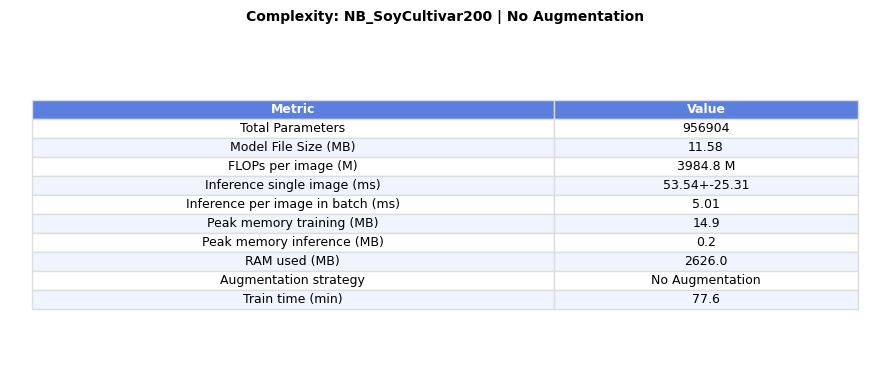

Complexity table saved.


In [13]:
# 1. Computational Complexity Table
import time as _t

try:
    from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
    concrete = tf.function(model).get_concrete_function(
        tf.TensorSpec([1] + list(IMG_SHAPE), tf.float32))
    frozen = convert_variables_to_constants_v2(concrete)
    graph  = frozen.graph
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops_val = tf.compat.v1.profiler.profile(
        graph=graph, run_meta=run_meta, cmd='op', options=opts)
    total_flops = flops_val.total_float_ops
    flops_str = str(round(total_flops / 1e6, 1)) + ' M'
except Exception as e:
    total_flops = -1
    flops_str = 'N/A (' + str(e)[:40] + ')'
    
dummy=tf.random.normal([1]+list(IMG_SHAPE))
for _ in range(3): model(dummy,training=False)
times_s=[]
for img,_ in test_ds.unbatch().batch(1).take(50):
    t0=_t.perf_counter(); model(img,training=False); times_s.append((_t.perf_counter()-t0)*1000)
times_b=[]
for img,_ in test_ds.take(20):
    t0=_t.perf_counter(); model(img,training=False); times_b.append((_t.perf_counter()-t0)*1000)

single_ms=np.mean(times_s); per_img_ms=np.mean(times_b)/BATCH_SIZE
tracemalloc.start()
for img,_ in test_ds.take(5): model(img,training=False)
_,inf_peak=tracemalloc.get_traced_memory(); tracemalloc.stop()
tmp_p='/tmp/_sz.h5'; model.save(tmp_p); sz_mb=os.path.getsize(tmp_p)/1e6; os.remove(tmp_p)

comp_df=pd.DataFrame({'Metric':[
    'Total Parameters','Model File Size (MB)', 'FLOPs per image (M)',
    'Inference single image (ms)','Inference per image in batch (ms)',
    'Peak memory training (MB)','Peak memory inference (MB)','RAM used (MB)',
    'Augmentation strategy','Train time (min)'],
'Value':[str(model.count_params()),str(round(sz_mb,2)),flops_str,
    str(round(single_ms,2))+'+-'+str(round(np.std(times_s),2)),str(round(per_img_ms,2)),
    str(round(peak_mem/1e6,1)),str(round(inf_peak/1e6,1)),str(round(ram_used_mb,0)),
    AUG_STRATEGY,str(round(train_time/60,1))]})
comp_df.to_csv(os.path.join(LOG_DIR,'complexity.csv'),index=False)

fig,ax=plt.subplots(figsize=(9,4)); ax.axis('off')
tbl=ax.table(cellText=comp_df.values,colLabels=['Metric','Value'],
             cellLoc='center',loc='center',colWidths=[0.6,0.35])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c),cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor('#5B7FDE'); cell.set_text_props(color='white',weight='bold')
    elif r%2==0: cell.set_facecolor('#F0F4FF')
    cell.set_edgecolor('#DDD')
ax.set_title('Complexity: '+NOTEBOOK_ID+' | '+AUG_STRATEGY,fontweight='bold',fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'complexity_table.png'),dpi=130,bbox_inches='tight'); plt.show()
print('Complexity table saved.')


Top 5 confusions:
  True=Cultivar_168                        Pred=Cultivar_159                        n=3
  True=Cultivar_050                        Pred=Cultivar_100                        n=3
  True=Cultivar_035                        Pred=Cultivar_055                        n=3
  True=Cultivar_199                        Pred=Cultivar_198                        n=2
  True=Cultivar_197                        Pred=Cultivar_112                        n=2


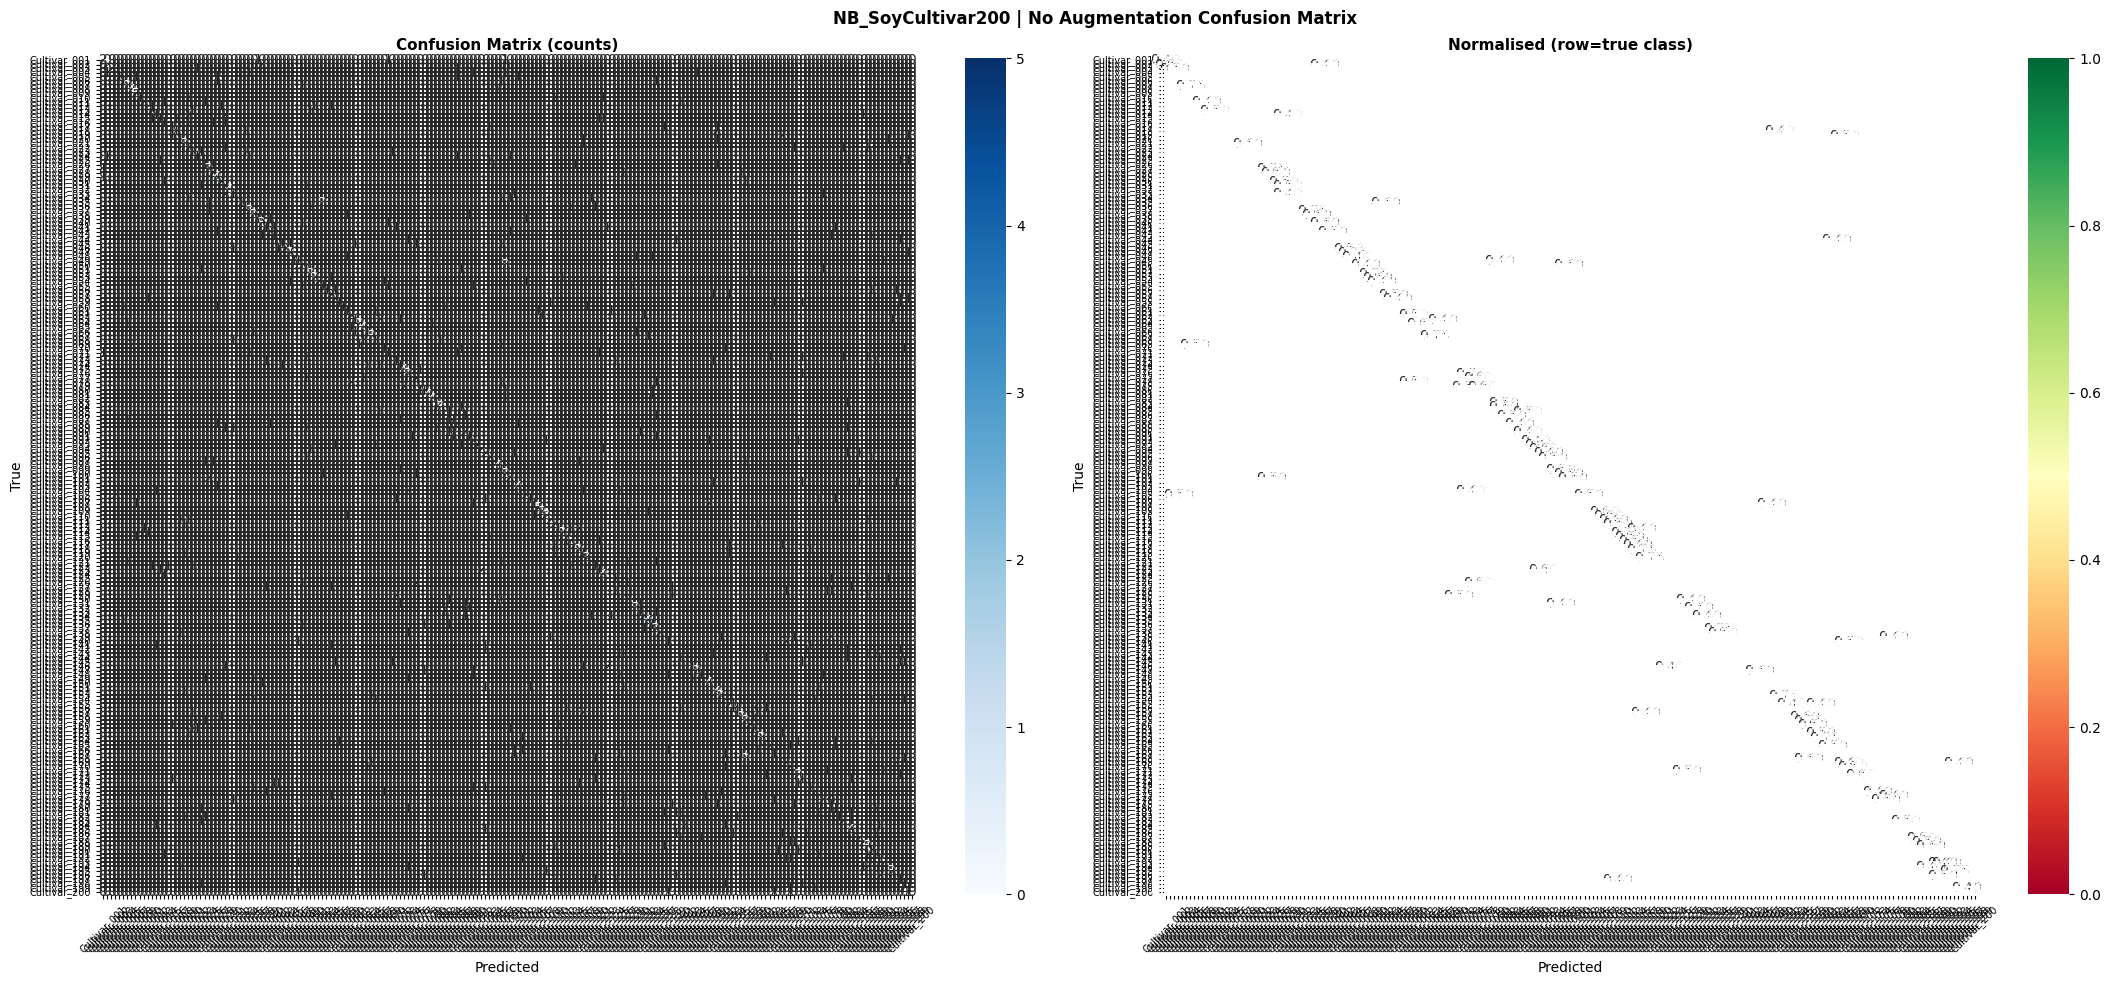

In [14]:
# 2. Confusion Matrix
cm=confusion_matrix(y_true,y_pred)
cm_norm=cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)
short=[c.replace('Cotton_','C.').replace('Wheat_','W.').replace('Potato_','P.')
        .replace('Bell_Pepper_','BP.').replace('Tomato_','T.') for c in TARGET_CLASSES]

fig,axes=plt.subplots(1,2,figsize=(22,10))
for ax,data,fmt,cmap,title in [
    (axes[0],cm,'d','Blues','Confusion Matrix (counts)'),
    (axes[1],cm_norm,'.2f','RdYlGn','Normalised (row=true class)'),
]:
    sns.heatmap(data,ax=ax,cmap=cmap,fmt=fmt,annot=True,
                xticklabels=short,yticklabels=short,
                linewidths=0.3,linecolor='white',
                **({'vmin':0,'vmax':1} if fmt=='.2f' else {}))
    ax.set_title(title,fontweight='bold',fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x',rotation=45,labelsize=7); ax.tick_params(axis='y',rotation=0,labelsize=7)

top5=sorted([(cm[i,j],TARGET_CLASSES[i],TARGET_CLASSES[j])
              for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i!=j],reverse=True)[:5]
print('Top 5 confusions:')
for cnt,t,p in top5: print('  True='+t.ljust(35)+' Pred='+p.ljust(35)+' n='+str(cnt))

plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Confusion Matrix',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'confusion_matrix.png'),dpi=130,bbox_inches='tight'); plt.show()


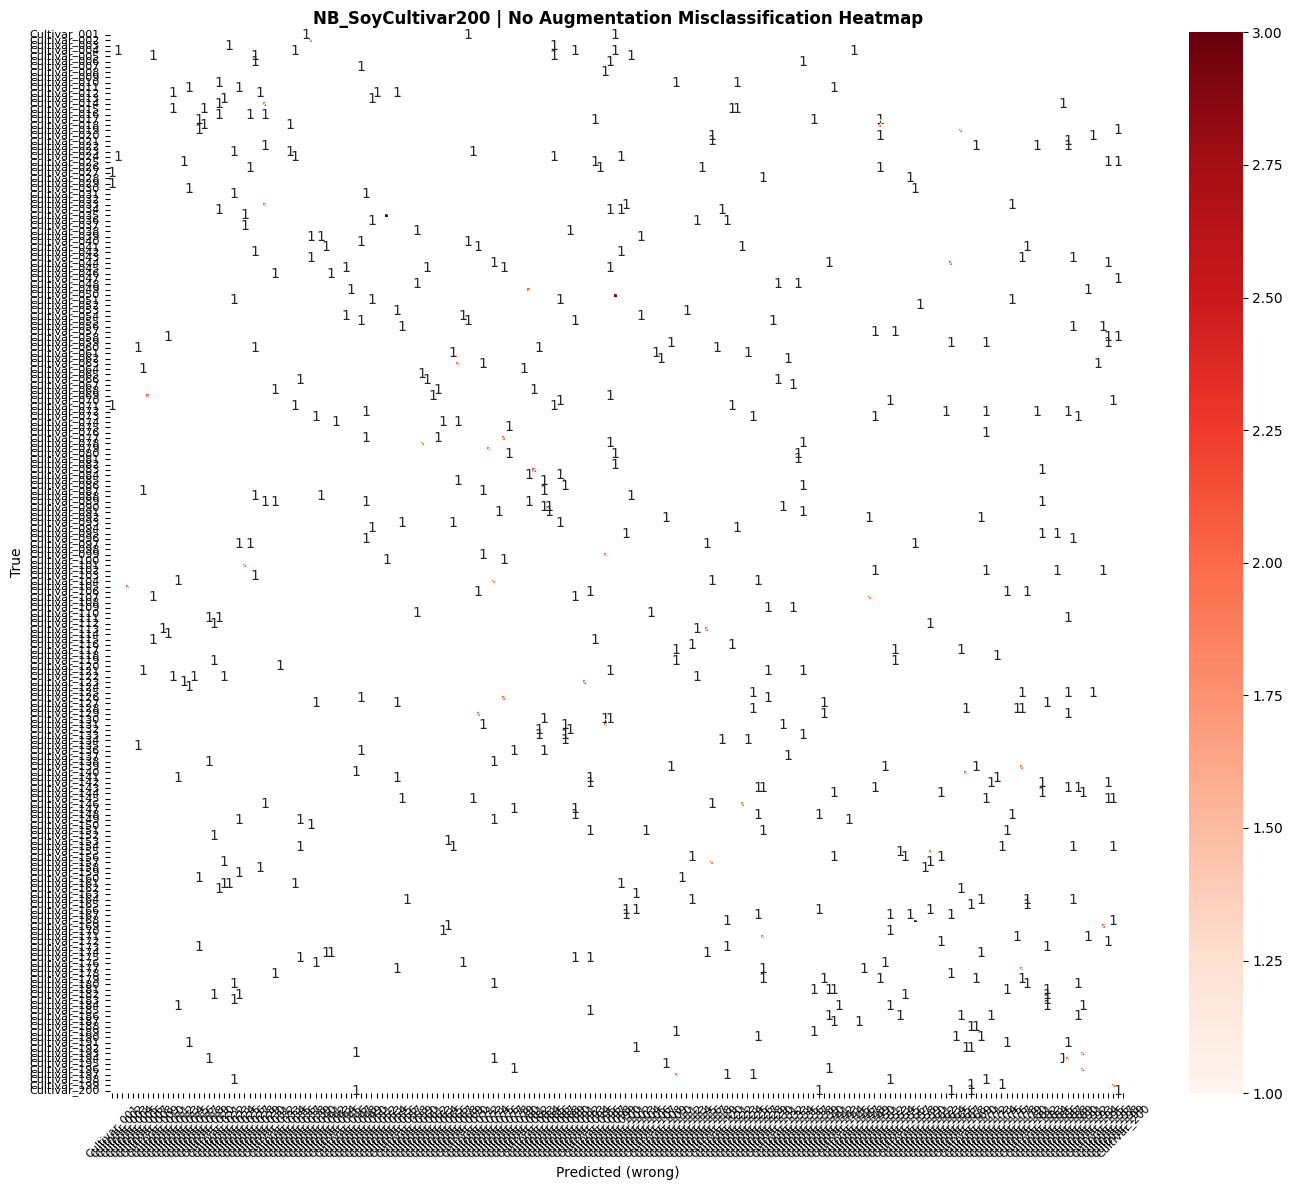

In [15]:
# 3. Misclassification Heatmap
cm_err=cm.copy(); np.fill_diagonal(cm_err,0)
fig,ax=plt.subplots(figsize=(14,12))
sns.heatmap(cm_err,ax=ax,cmap='Reds',annot=True,fmt='d',
            xticklabels=short,yticklabels=short,linewidths=0.3,linecolor='white',
            mask=(cm_err==0))
ax.set_title(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Misclassification Heatmap',fontweight='bold')
ax.set_xlabel('Predicted (wrong)'); ax.set_ylabel('True')
ax.tick_params(axis='x',rotation=45,labelsize=8); ax.tick_params(axis='y',rotation=0,labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'misclassification_heatmap.png'),dpi=130,bbox_inches='tight'); plt.show()


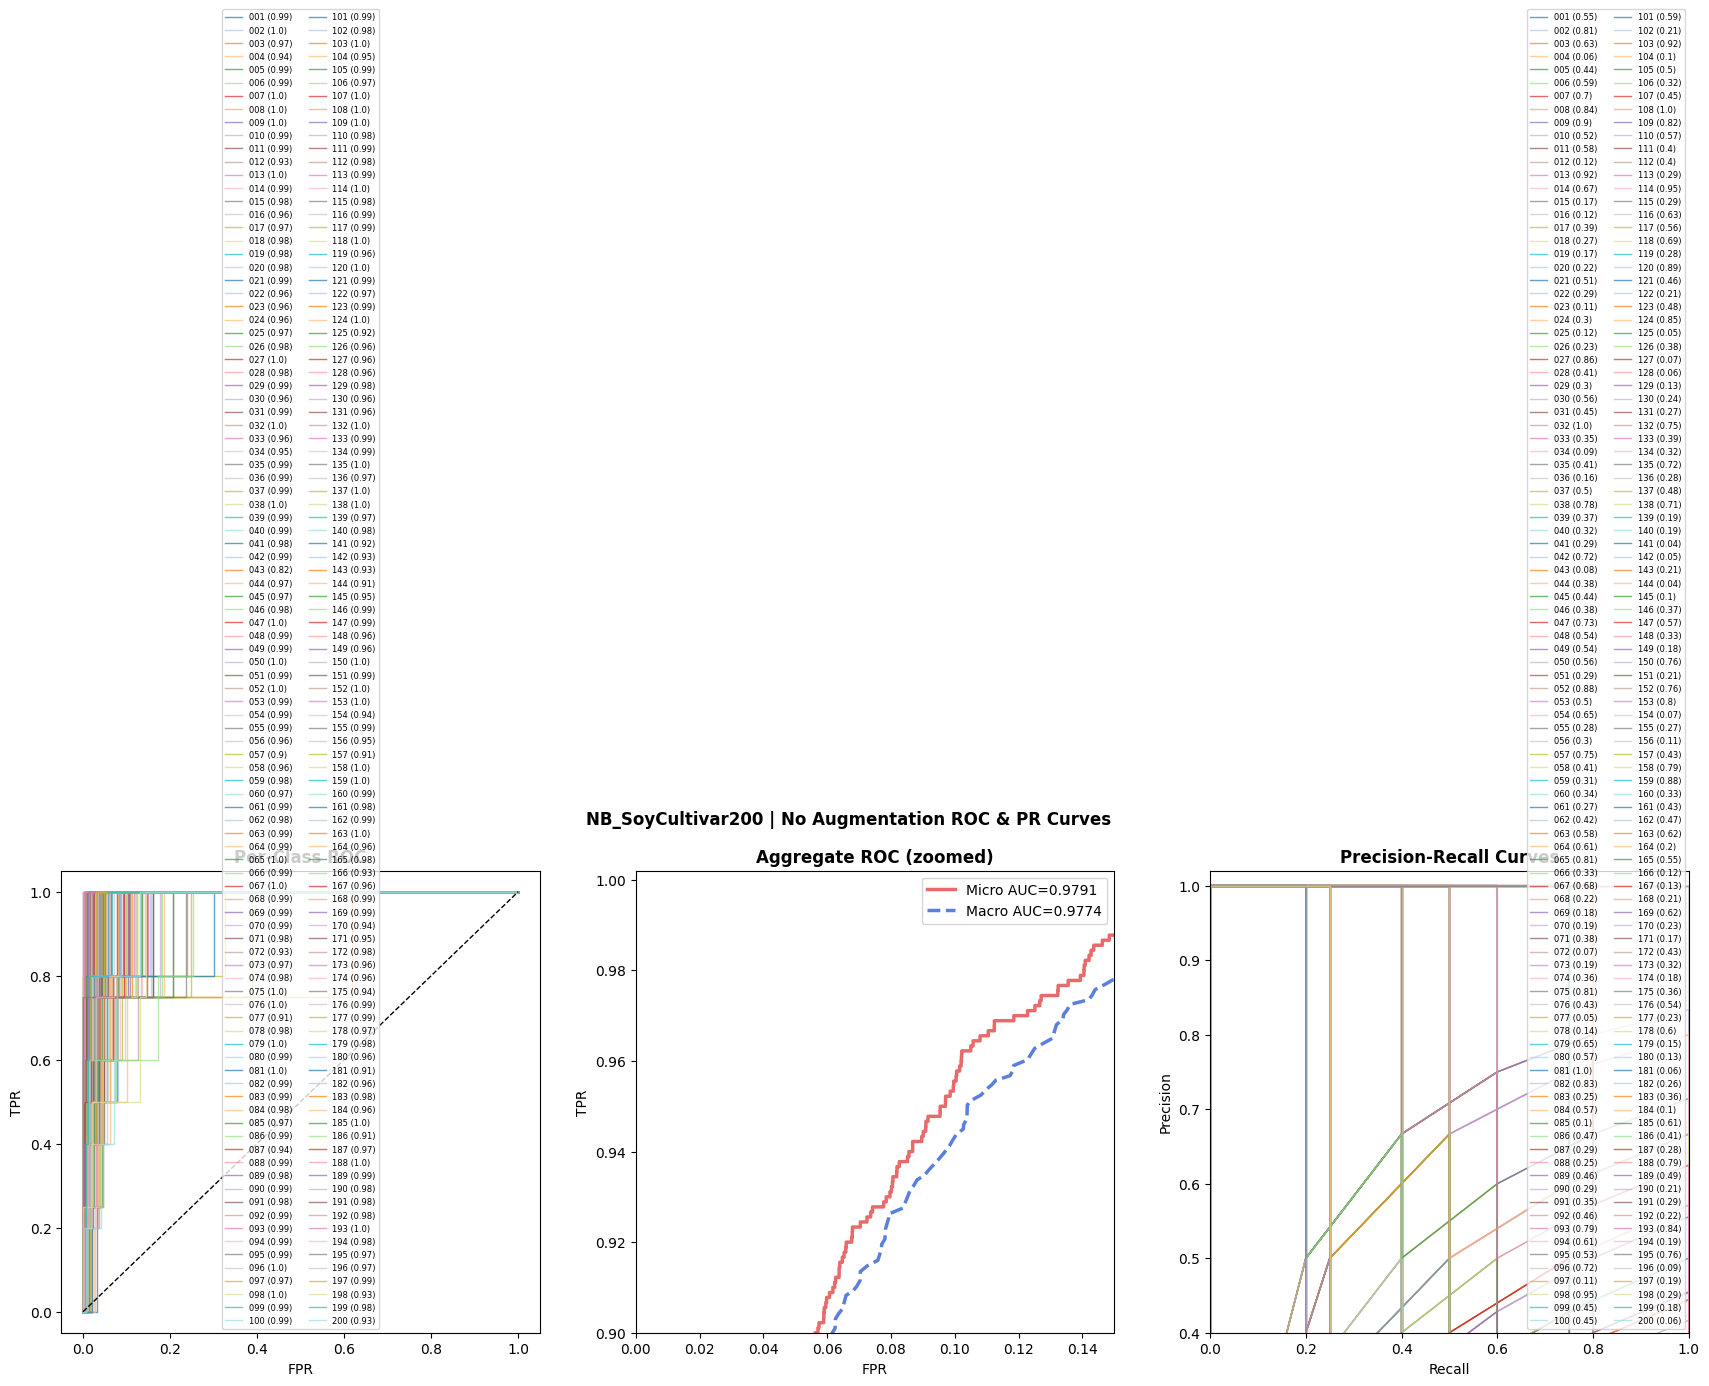

Micro AUC=0.9791  Macro AUC=0.9774


In [16]:
# 4. ROC + PR Curves
y_bin=label_binarize(y_true,classes=list(range(NUM_CLASSES)))
fpr_d,tpr_d,roc_auc_d,pr_ap={},{},{},{}
for i in range(NUM_CLASSES):
    fpr_d[i],tpr_d[i],_=roc_curve(y_bin[:,i],y_prob[:,i]); roc_auc_d[i]=auc(fpr_d[i],tpr_d[i])
    pr_ap[i]=average_precision_score(y_bin[:,i],y_prob[:,i])

fpr_d['micro'],tpr_d['micro'],_=roc_curve(y_bin.ravel(),y_prob.ravel())
roc_auc_d['micro']=auc(fpr_d['micro'],tpr_d['micro'])
all_fpr=np.unique(np.concatenate([fpr_d[i] for i in range(NUM_CLASSES)]))
mean_tpr=np.zeros_like(all_fpr)
for i in range(NUM_CLASSES): mean_tpr+=np.interp(all_fpr,fpr_d[i],tpr_d[i])
mean_tpr/=NUM_CLASSES; roc_auc_d['macro']=auc(all_fpr,mean_tpr)

fig,axes=plt.subplots(1,3,figsize=(21,6))
for i,color in zip(range(NUM_CLASSES),cycle(plt.cm.tab20.colors)):
    axes[0].plot(fpr_d[i],tpr_d[i],color=color,lw=1,alpha=0.7,
                 label=TARGET_CLASSES[i].split('_')[-1]+' ('+str(round(roc_auc_d[i],2))+')')
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_title('Per-Class ROC',fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=6,ncol=2)

axes[1].plot(fpr_d['micro'],tpr_d['micro'],'#E86B6B',lw=2.5,label='Micro AUC='+str(round(roc_auc_d["micro"],4)))
axes[1].plot(all_fpr,mean_tpr,'#5B7FDE',lw=2.5,ls='--',label='Macro AUC='+str(round(roc_auc_d["macro"],4)))
axes[1].plot([0,1],[0,1],'k--',lw=1); axes[1].set_xlim([0,0.15]); axes[1].set_ylim([0.9,1.002])
axes[1].set_title('Aggregate ROC (zoomed)',fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=10)

for i,color in zip(range(NUM_CLASSES),cycle(plt.cm.tab20.colors)):
    p_i,r_i,_=precision_recall_curve(y_bin[:,i],y_prob[:,i])
    axes[2].plot(r_i,p_i,color=color,lw=1,alpha=0.7,
                 label=TARGET_CLASSES[i].split('_')[-1]+' ('+str(round(pr_ap[i],2))+')')
axes[2].set_title('Precision-Recall Curves',fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_xlim([0,1]); axes[2].set_ylim([0.4,1.02]); axes[2].legend(fontsize=6,ncol=2)

plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' ROC & PR Curves',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'roc_pr_curves.png'),dpi=130,bbox_inches='tight'); plt.show()
print('Micro AUC='+str(round(roc_auc_d["micro"],4))+'  Macro AUC='+str(round(roc_auc_d["macro"],4)))


In [17]:
print("len(y_true):", len(y_true))
print("NUM_CLASSES:", NUM_CLASSES)
print("classes:", list(range(NUM_CLASSES)))
print("y_prob shape:", y_prob.shape)

y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
print("y_bin shape:", y_bin.shape)

len(y_true): 900
NUM_CLASSES: 200
classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199]
y_prob shape: (900, 200)
y_bin shape: (900, 200)


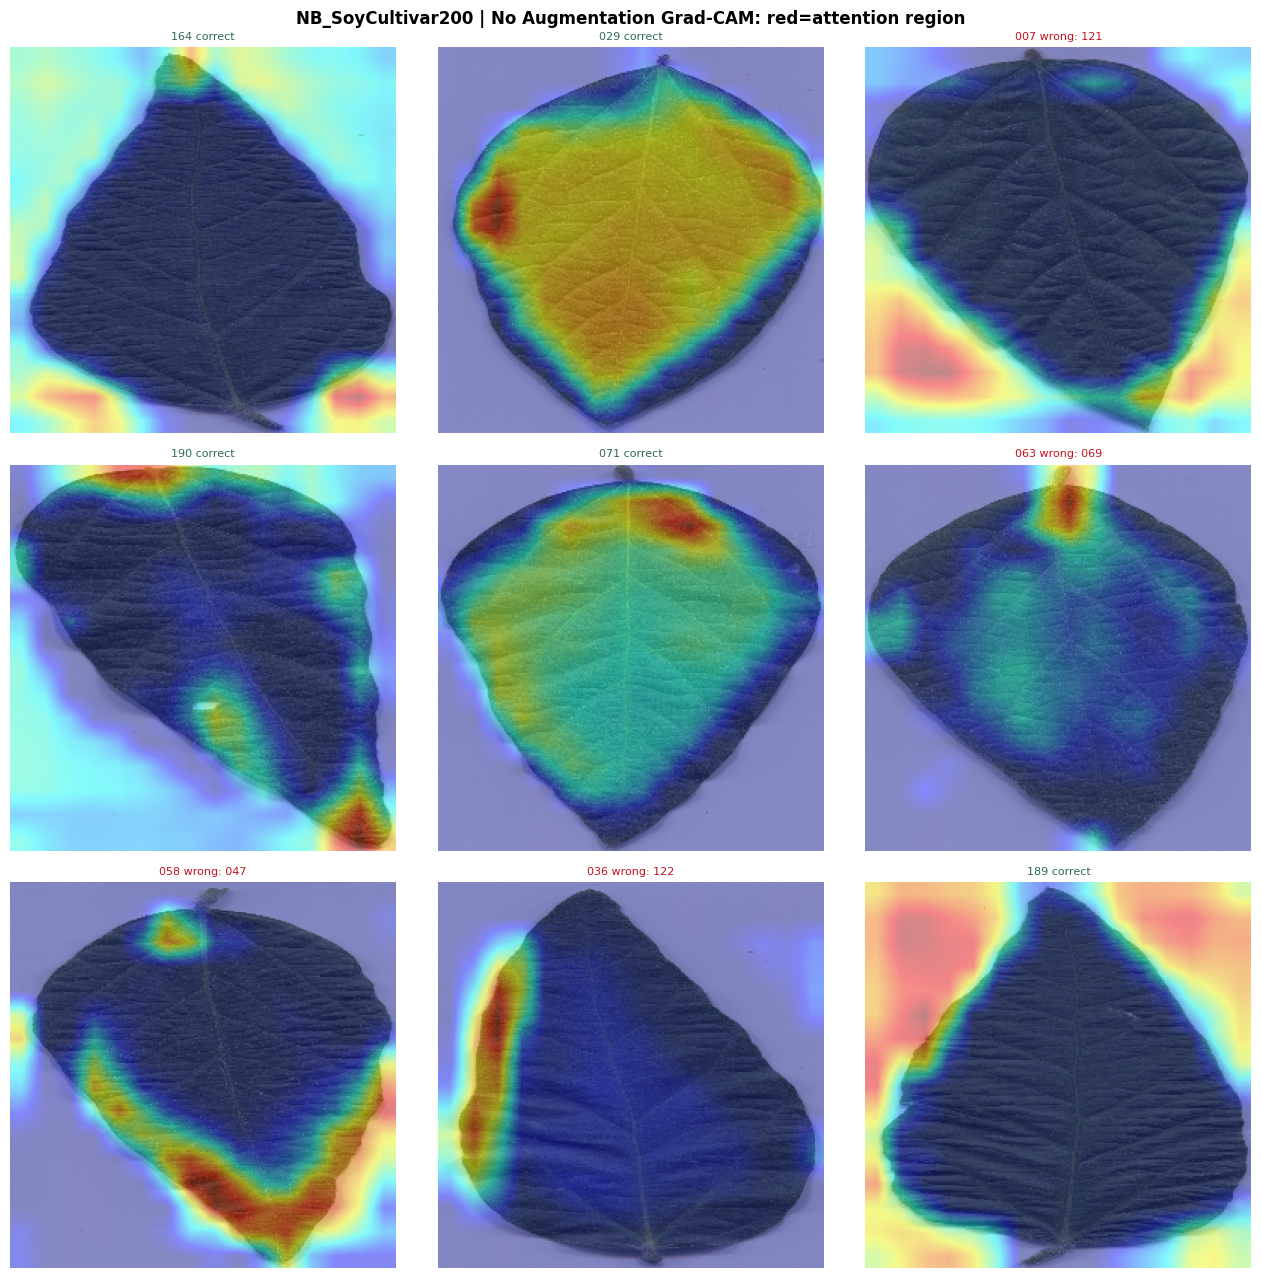

In [18]:
# 5. Grad-CAM
try: import cv2
except: os.system('pip install opencv-python-headless -q'); import cv2

last_conv=next(l.name for l in reversed(model.layers)
               if isinstance(l,(tf.keras.layers.Conv2D,tf.keras.layers.MaxPooling2D)))
grad_model=tf.keras.Model(inputs=model.input,
                           outputs=[model.get_layer(last_conv).output,model.output])

def gradcam(img_t,cls_idx):
    with tf.GradientTape() as tape:
        conv_out,preds=grad_model(img_t[tf.newaxis],training=False)
        score=preds[0][cls_idx]
    grads=tape.gradient(score,conv_out)[0]
    weights=tf.reduce_mean(grads,axis=[0,1])
    cam=tf.reduce_sum(conv_out[0]*weights,axis=-1).numpy()
    cam=np.maximum(cam,0); cam/=(cam.max()+1e-8)
    return cv2.resize(cam,(256,256))

def overlay(img_np,cam):
    hm=cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam),cv2.COLORMAP_JET),cv2.COLOR_BGR2RGB)/255.0
    return np.clip(0.55*img_np+0.45*hm,0,1)

random.seed(SEED)
sample_cls=random.sample(TARGET_CLASSES,9)
fig,axes=plt.subplots(3,3,figsize=(13,13))
for ax,cls in zip(axes.flatten(),sample_cls):
    imgs=get_images(os.path.join(UNIFIED_DIR,cls))
    if not imgs: ax.axis('off'); continue
    path=random.choice(imgs)
    raw=tf.io.read_file(path)
    img_t=tf.cast(tf.image.resize(tf.image.decode_image(raw,channels=3,expand_animations=False),IMG_SIZE),tf.float32)/255.0
    cls_idx=CLASS_TO_IDX[cls]
    cam=gradcam(img_t,cls_idx)
    over=overlay(img_t.numpy(),cam)
    pred=np.argmax(model(img_t[tf.newaxis],training=False).numpy()[0])
    correct=pred==cls_idx; col='#2d6a4f' if correct else '#c1121f'
    ax.imshow(over)
    verdict = 'correct' if correct else 'wrong: '+IDX_TO_CLASS[pred].split('_')[-1]
    ax.set_title(cls.split('_')[-1]+' '+verdict, fontsize=8, color=col)
    for sp in ax.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(2)
    ax.axis('off')
plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Grad-CAM: red=attention region',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'gradcam.png'),dpi=130,bbox_inches='tight'); plt.show()


29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 397ms/step
t-SNE on 900 samples x 224 dims ...


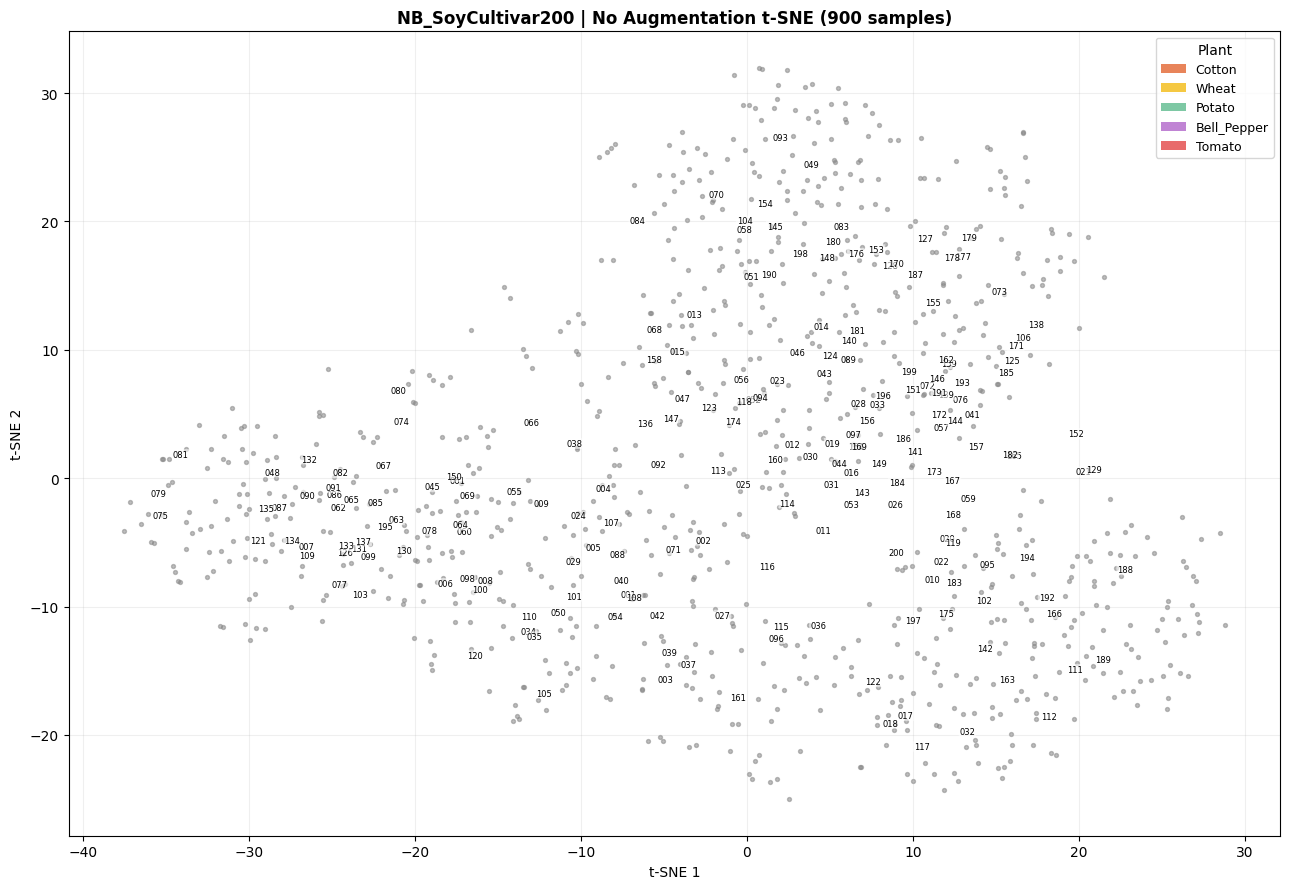

In [19]:
# 6. t-SNE Feature Space
gap_layer_name='gap' if 'gap' in [l.name for l in model.layers] else model.layers[-4].name
gap_model=tf.keras.Model(inputs=model.input,outputs=model.get_layer(gap_layer_name).output)

MAX_T=2500
X_sub=X_te[:MAX_T]; y_sub=y_te[:MAX_T]
ds_sub=tf.data.Dataset.from_tensor_slices((X_sub,y_sub)).map(
    lambda p,l: (tf.cast(tf.image.resize(
        tf.image.decode_image(tf.io.read_file(p),channels=3,expand_animations=False),
        IMG_SIZE),tf.float32)/255.0, l)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
feats=gap_model.predict(ds_sub,verbose=1)[:MAX_T]; lbl_s=y_sub[:len(feats)]

print('t-SNE on '+str(len(feats))+' samples x '+str(feats.shape[1])+' dims ...')
emb=TSNE(n_components=2,perplexity=40,n_iter=1000,random_state=SEED).fit_transform(feats)

PCOLS={'Cotton':'#E8845A','Wheat':'#F5C842','Potato':'#7EC8A4','Bell_Pepper':'#C084D4','Tomato':'#E86B6B'}
def pcol(cls):
    for k in PCOLS:
        if cls.startswith(k): return PCOLS[k]
    return '#888'

fig,ax=plt.subplots(figsize=(13,9))
for ci,cls in enumerate(TARGET_CLASSES):
    mask=lbl_s==ci
    if not mask.any(): continue
    ax.scatter(emb[mask,0],emb[mask,1],s=8,alpha=0.55,color=pcol(cls))
    cx,cy=emb[mask,0].mean(),emb[mask,1].mean()
    ax.text(cx,cy,cls.split('_')[-1][:7],fontsize=6,ha='center',
            bbox=dict(boxstyle='round,pad=0.1',facecolor='white',alpha=0.6,edgecolor='none'))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v,label=k) for k,v in PCOLS.items()],title='Plant',fontsize=9)
ax.set_title(NOTEBOOK_ID+' | '+AUG_STRATEGY+' t-SNE ('+str(len(feats))+' samples)',fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'tsne.png'),dpi=130,bbox_inches='tight'); plt.show()


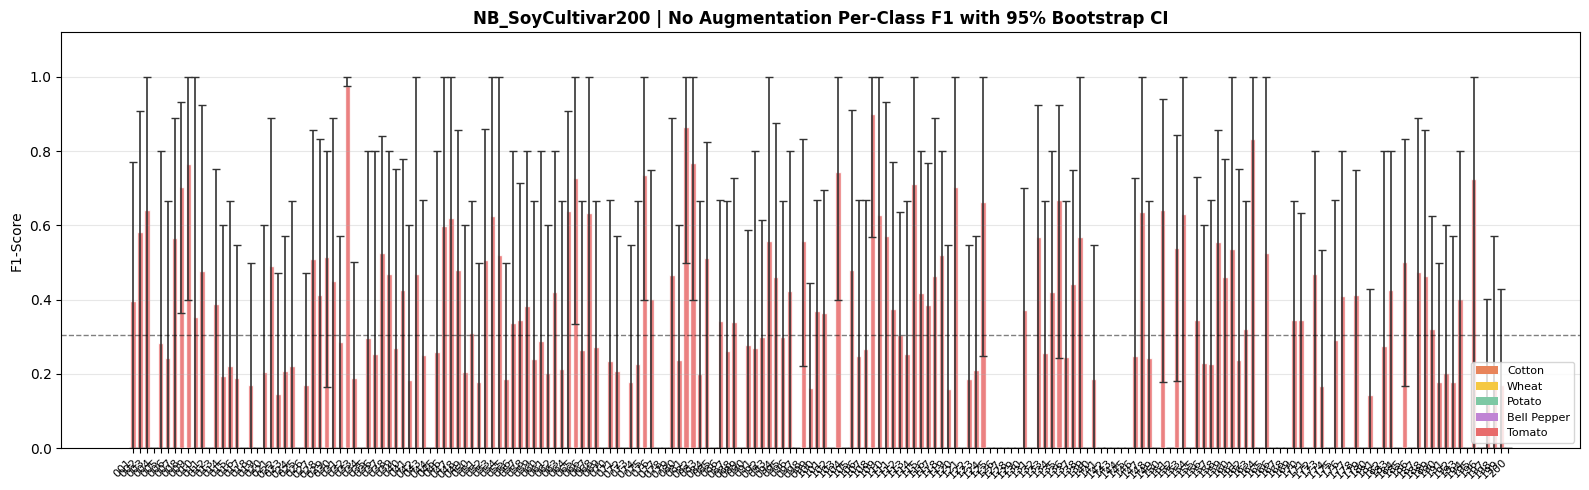

In [20]:
# 7. Per-class F1 with Bootstrap CI
N_BOOT=200; boot_f1s={cls:[] for cls in TARGET_CLASSES}
rng=np.random.default_rng(SEED)
for _ in range(N_BOOT):
    idx=rng.choice(len(y_true),len(y_true),replace=True)
    yt_b=y_true[idx]; yp_b=y_pred[idx]
    for ci,cls in enumerate(TARGET_CLASSES):
        tp=np.sum((yt_b==ci)&(yp_b==ci)); fp=np.sum((yt_b!=ci)&(yp_b==ci)); fn=np.sum((yt_b==ci)&(yp_b!=ci))
        boot_f1s[cls].append((2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0)

means=[np.mean(boot_f1s[c]) for c in TARGET_CLASSES]
ci_lo=[np.percentile(boot_f1s[c],2.5) for c in TARGET_CLASSES]
ci_hi=[np.percentile(boot_f1s[c],97.5) for c in TARGET_CLASSES]

plant_colors=['#E8845A' if c.startswith('Cotton') else '#F5C842' if c.startswith('Wheat')
              else '#7EC8A4' if c.startswith('Potato') else '#C084D4' if c.startswith('Bell') else '#E86B6B'
              for c in TARGET_CLASSES]

fig,ax=plt.subplots(figsize=(16,5))
x=np.arange(NUM_CLASSES)
ax.bar(x,means,color=plant_colors,alpha=0.85,edgecolor='white')
yerr_lo=np.abs([m-l for m,l in zip(means,ci_lo)])
yerr_hi=np.abs([h-m for h,m in zip(ci_hi,means)])
ax.errorbar(x,means,yerr=[yerr_lo,yerr_hi],
            fmt='none',color='#333',capsize=3,lw=1.2)
ax.set_xticks(x); ax.set_xticklabels([c.split('_')[-1][:8] for c in TARGET_CLASSES],rotation=45,ha='right',fontsize=8)
ax.set_ylim(0,1.12); ax.set_ylabel('F1-Score'); ax.grid(True,axis='y',alpha=0.3)
ax.axhline(np.mean(means),color='black',ls='--',lw=1,alpha=0.5,label='Mean='+str(round(float(np.mean(means)),3)))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#E8845A',label='Cotton'),Patch(facecolor='#F5C842',label='Wheat'),
    Patch(facecolor='#7EC8A4',label='Potato'),Patch(facecolor='#C084D4',label='Bell Pepper'),
    Patch(facecolor='#E86B6B',label='Tomato')],fontsize=8,loc='lower right')
ax.set_title(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Per-Class F1 with 95% Bootstrap CI',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'per_class_f1_ci.png'),dpi=130,bbox_inches='tight'); plt.show()


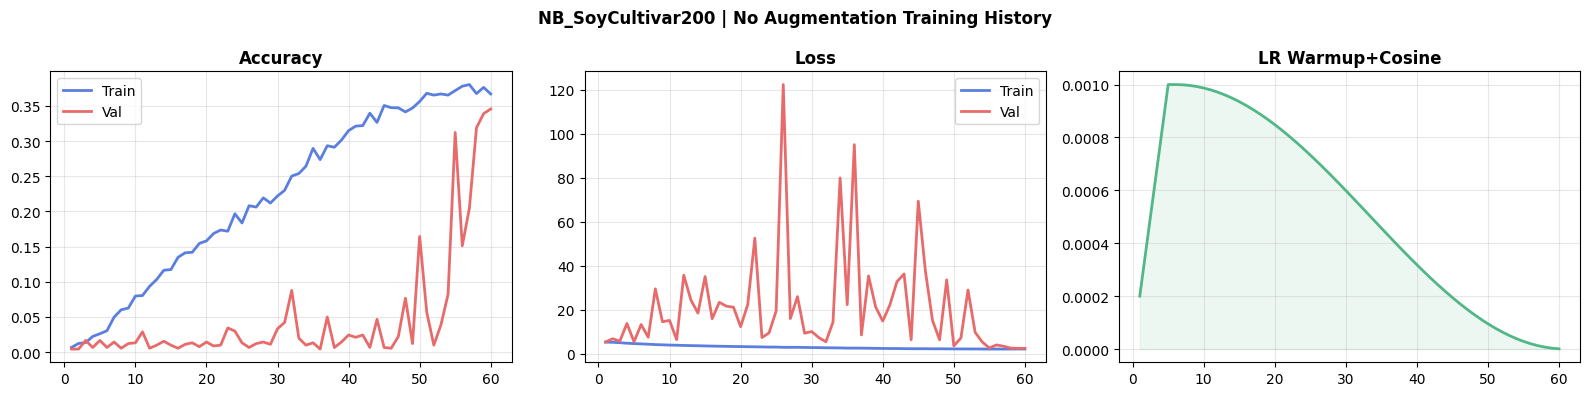

FINAL: acc=0.3444 f1=0.3278 macro_auc=0.9774
All files saved to /root/plant_project/NB_SoyCultivar200/logs/visualizations


In [21]:
# 8. Training curves + save all
hist=history.history; n_ep=range(1,len(hist['loss'])+1)
fig,axes=plt.subplots(1,3,figsize=(16,4))
axes[0].plot(n_ep,hist['accuracy'],label='Train',color='#5B7FDE',lw=2)
axes[0].plot(n_ep,hist['val_accuracy'],label='Val',color='#E86B6B',lw=2)
axes[0].set_title('Accuracy',fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(n_ep,hist['loss'],label='Train',color='#5B7FDE',lw=2)
axes[1].plot(n_ep,hist['val_loss'],label='Val',color='#E86B6B',lw=2)
axes[1].set_title('Loss',fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
lrs=[CosineWarmupScheduler(INITIAL_LR,EPOCHS)._sched(e,0) for e in range(len(hist['loss']))]
axes[2].plot(n_ep,lrs,color='#52B788',lw=2); axes[2].fill_between(n_ep,lrs,alpha=0.1,color='#52B788')
axes[2].set_title('LR Warmup+Cosine',fontweight='bold'); axes[2].grid(alpha=0.3)
plt.suptitle(NOTEBOOK_ID+' | '+AUG_STRATEGY+' Training History',fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(LOG_DIR,'training_curves.png'),dpi=120,bbox_inches='tight'); plt.show()

pd.DataFrame(hist).assign(epoch=range(1,len(hist['loss'])+1),notebook=NOTEBOOK_ID,
    aug=AUG_STRATEGY,train_time_sec=train_time,total_params=model.count_params()
).to_csv(os.path.join(LOG_DIR,'training_history.csv'),index=False)

pd.DataFrame([{'notebook':NOTEBOOK_ID,'aug_strategy':AUG_STRATEGY,'accuracy':acc,
    'precision':prec,'recall':rec,'f1':f1,'specificity':float(np.mean(spec_list)),
    'params':model.count_params(),'train_time_min':train_time/60,'model_size_mb':sz_mb,
    'single_inf_ms':single_ms,'per_img_batch_ms':per_img_ms,
    'peak_train_mem_mb':peak_mem/1e6,'peak_inf_mem_mb':inf_peak/1e6,
    'micro_auc':roc_auc_d['micro'],'macro_auc':roc_auc_d['macro'],
    'mean_ap':float(np.mean(list(pr_ap.values()))),'best_val_acc':max(hist['val_accuracy'])
}]).to_csv(os.path.join(LOG_DIR,'metrics_summary.csv'),index=False)

pd.DataFrame({'class':TARGET_CLASSES,'f1_mean':means,'ci_lo':ci_lo,'ci_hi':ci_hi,
    'sensitivity':[rd[c]['recall'] for c in TARGET_CLASSES],
    'precision_cls':[rd[c]['precision'] for c in TARGET_CLASSES],
    'specificity':spec_list,'support':[rd[c]['support'] for c in TARGET_CLASSES]
}).to_csv(os.path.join(LOG_DIR,'per_class_metrics.csv'),index=False)

pd.DataFrame({'class':list(range(NUM_CLASSES))+['micro','macro'],
    'class_name':TARGET_CLASSES+['micro_avg','macro_avg'],
    'roc_auc':[roc_auc_d[i] for i in range(NUM_CLASSES)]+[roc_auc_d['micro'],roc_auc_d['macro']],
    'avg_precision':list(pr_ap.values())+[float(np.mean(list(pr_ap.values())))]*2
}).to_csv(os.path.join(LOG_DIR,'roc_auc.csv'),index=False)

np.save(os.path.join(LOG_DIR,'y_prob.npy'),y_prob); np.save(os.path.join(LOG_DIR,'y_true.npy'),y_true)
model.save(os.path.join(BASE_DIR,'model.h5'))

with open(os.path.join(BASE_DIR,'class_mapping.json'),'w') as f:
    json.dump({'idx_to_class':IDX_TO_CLASS,'class_to_idx':CLASS_TO_IDX,'notebook':NOTEBOOK_ID,'aug':AUG_STRATEGY},f,indent=2)

import shutil
dst=os.path.join('/kaggle/working','plant_project',NOTEBOOK_ID)
if os.path.exists(dst): shutil.rmtree(dst)
shutil.copytree(BASE_DIR,dst)
print('FINAL: acc='+str(round(acc,4))+' f1='+str(round(f1,4))+' macro_auc='+str(round(roc_auc_d["macro"],4)))
print('All files saved to '+VIZ_DIR)

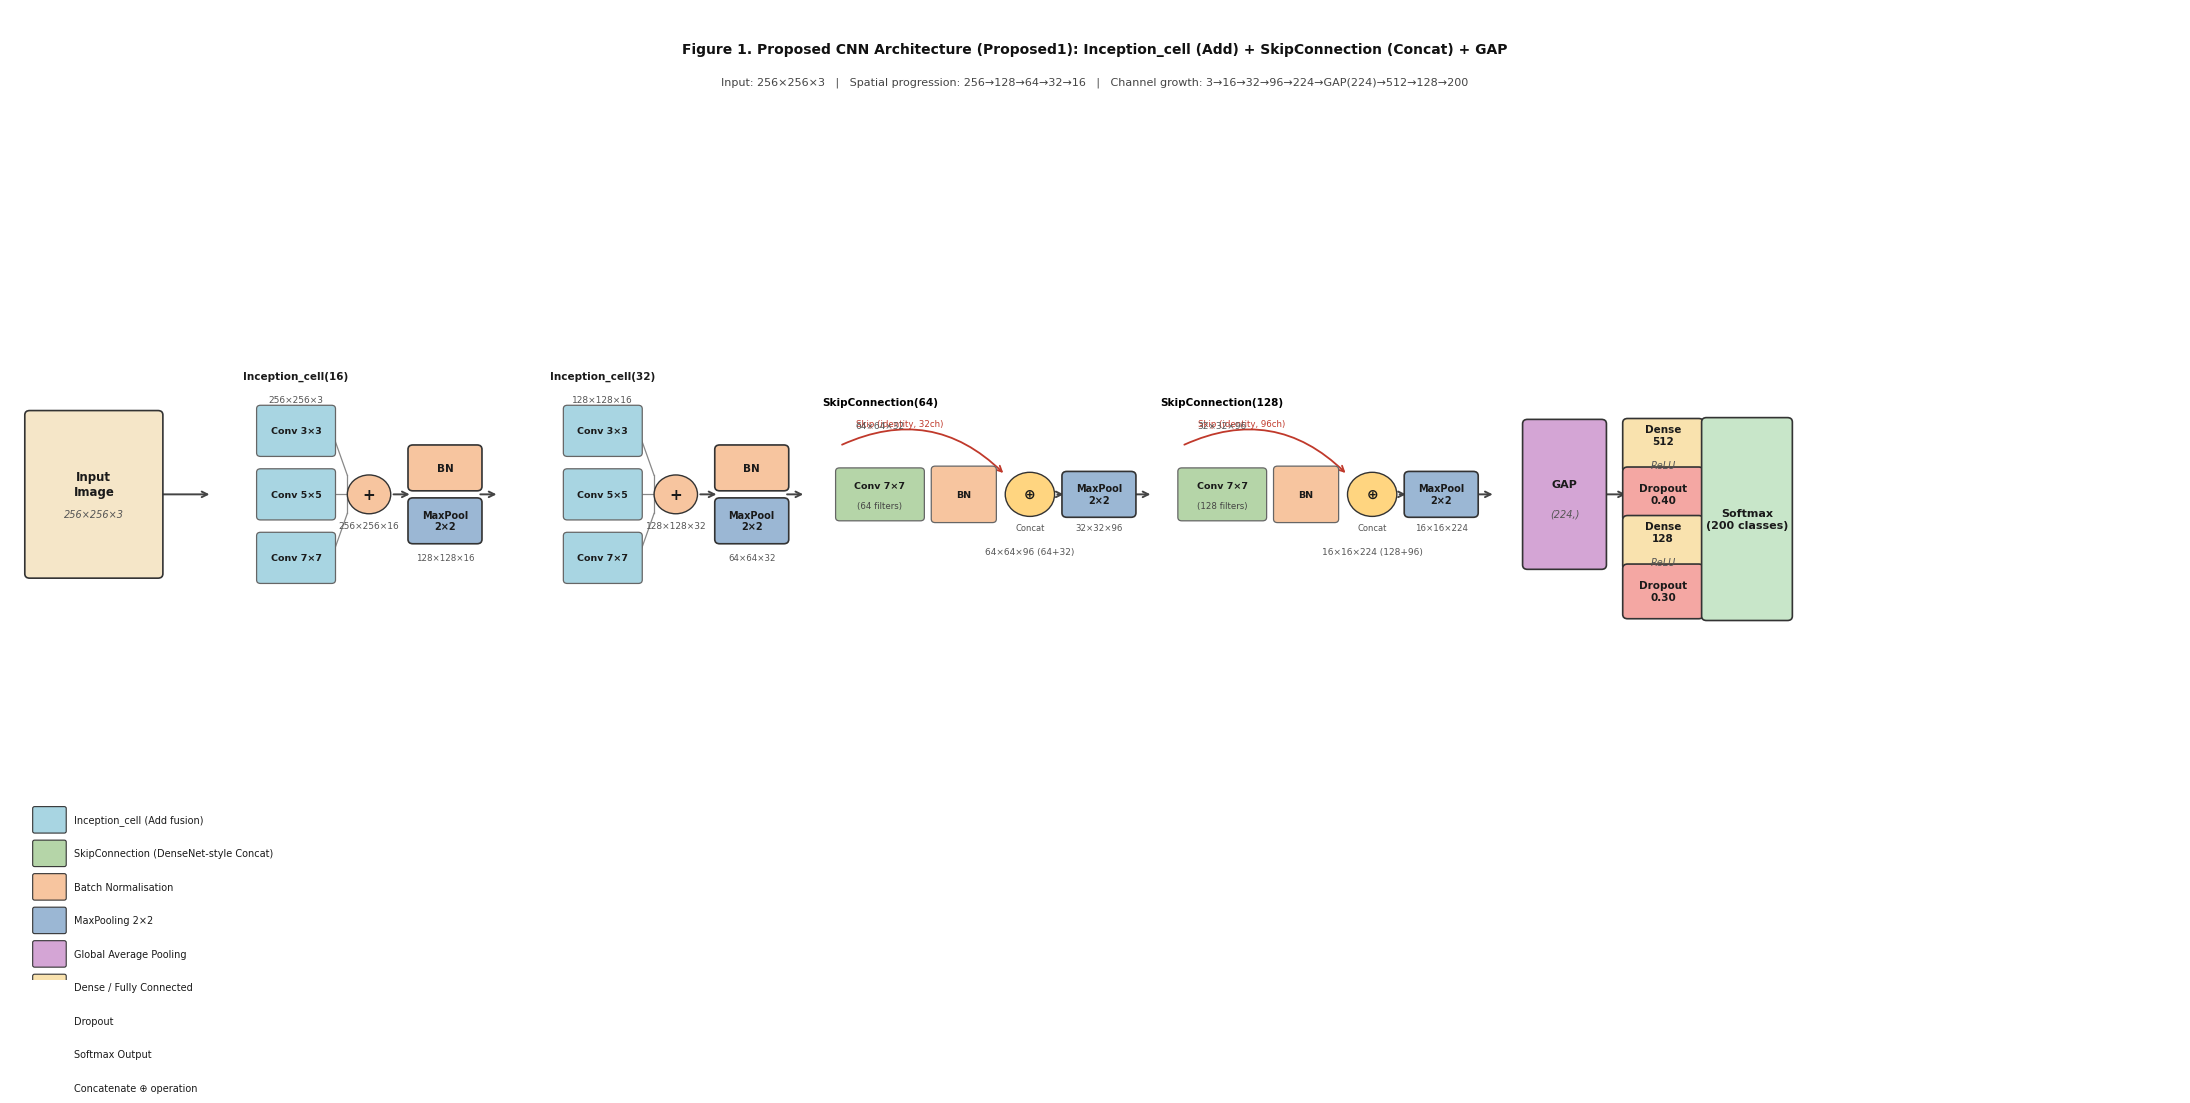

Architecture diagram saved:
  /root/plant_project/NB_SoyCultivar200/logs/visualizations/architecture_diagram.pdf
  /root/plant_project/NB_SoyCultivar200/logs/visualizations/architecture_diagram.png
Use the PDF for journal submission (vector, no pixelation at any zoom).


In [22]:
# ════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE DIAGRAM — publication quality (matplotlib, no extra installs)
# Style matches standard CNN diagrams used in IEEE/Springer journals
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(figsize=(22, 11))
ax.set_xlim(0, 22); ax.set_ylim(0, 11)
ax.axis('off')

# ── Colour palette ────────────────────────────────────────────────────────
C_INPUT   = '#F5E6C8'   # warm cream
C_INC     = '#A8D5E2'   # blue — inception cell
C_BN      = '#F7C59F'   # orange — batch norm
C_POOL    = '#9BB7D4'   # steel — pooling
C_SKIP    = '#B5D5A8'   # green — skip connection
C_GAP     = '#D4A5D5'   # purple — GAP
C_DENSE   = '#F9E2AE'   # yellow — dense
C_DROP    = '#F4A7A3'   # red — dropout
C_OUT     = '#C8E6C9'   # light green — output
EDGE      = '#333333'
TEXT_COL  = '#1a1a1a'

def block(ax, x, y, w, h, label, sublabel='', color='#EEEEEE', fontsize=8, sublabel_size=7):
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.05",
                          linewidth=1.2, edgecolor=EDGE, facecolor=color, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y + (0.12 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=TEXT_COL, zorder=4)
    if sublabel:
        ax.text(x, y - 0.22, sublabel,
                ha='center', va='center', fontsize=sublabel_size,
                color='#555555', style='italic', zorder=4)

def arrow(ax, x1, y1, x2, y2, label='', color='#444444'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.4),
                zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.05, my + 0.18, label,
                ha='left', va='center', fontsize=6.5,
                color='#666666', zorder=5)

def inception_block(ax, cx, cy, label, in_shape, out_shape, filters):
    """Draw an Inception_cell as three parallel sub-blocks + Add"""
    bw, bh = 0.72, 0.50
    gap_y  = 0.72
    ys     = [cy + gap_y, cy, cy - gap_y]
    names  = ['Conv 3×3', 'Conv 5×5', 'Conv 7×7']
    for yi, nm in zip(ys, names):
        rect = FancyBboxPatch((cx - bw/2, yi - bh/2), bw, bh,
                              boxstyle="round,pad=0.04",
                              linewidth=0.9, edgecolor='#666', facecolor=C_INC, zorder=3)
        ax.add_patch(rect)
        ax.text(cx, yi, nm, ha='center', va='center', fontsize=6.8,
                fontweight='bold', color=TEXT_COL, zorder=4)
    # Add circle
    circle = plt.Circle((cx + bw/2 + 0.38, cy), 0.22,
                         color=C_BN, ec=EDGE, lw=1.0, zorder=3)
    ax.add_patch(circle)
    ax.text(cx + bw/2 + 0.38, cy, '+', ha='center', va='center',
            fontsize=11, fontweight='bold', color='#1a1a1a', zorder=4)
    # Connecting lines from branches to Add
    for yi in ys:
        ax.plot([cx + bw/2, cx + bw/2 + 0.16], [yi, cy + (yi-cy)*0.3],
                color='#888', lw=0.9, zorder=2)
        ax.plot([cx + bw/2 + 0.16, cx + bw/2 + 0.16], [cy + (yi-cy)*0.3, cy],
                color='#888', lw=0.9, zorder=2)
    # Outer label
    ax.text(cx, cy + gap_y + 0.62,
            f'Inception_cell({filters})', ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='#1a1a1a', zorder=4)
    ax.text(cx, cy + gap_y + 0.35, in_shape,
            ha='center', va='center', fontsize=6.5, color='#555555', zorder=4)
    ax.text(cx + bw/2 + 0.38, cy - 0.35, out_shape,
            ha='center', va='center', fontsize=6.5, color='#555555', zorder=4)
    return cx + bw/2 + 0.38 + 0.22   # right edge x

def skip_block(ax, cx, cy, label, in_shape, out_shape, conv_f, in_ch):
    """Draw a SkipConnection as Conv + BN + Concat(input)"""
    bw, bh = 0.82, 0.52
    # Conv box
    rect1 = FancyBboxPatch((cx - bw/2, cy - bh/2), bw, bh,
                           boxstyle="round,pad=0.04",
                           linewidth=0.9, edgecolor='#666', facecolor=C_SKIP, zorder=3)
    ax.add_patch(rect1)
    ax.text(cx, cy + 0.10, f'Conv 7×7', ha='center', va='center',
            fontsize=6.8, fontweight='bold', color=TEXT_COL, zorder=4)
    ax.text(cx, cy - 0.13, f'({conv_f} filters)', ha='center', va='center',
            fontsize=6.2, color='#444', zorder=4)
    # BN box
    rect2 = FancyBboxPatch((cx + bw/2 + 0.15, cy - 0.28), 0.58, 0.56,
                           boxstyle="round,pad=0.04",
                           linewidth=0.9, edgecolor='#666', facecolor=C_BN, zorder=3)
    ax.add_patch(rect2)
    ax.text(cx + bw/2 + 0.44, cy, 'BN', ha='center', va='center',
            fontsize=6.8, fontweight='bold', color=TEXT_COL, zorder=4)
    # Concat circle
    cat_x = cx + bw/2 + 0.15 + 0.58 + 0.38
    circle = plt.Circle((cat_x, cy), 0.25,
                         color='#FFD580', ec=EDGE, lw=1.0, zorder=3)
    ax.add_patch(circle)
    ax.text(cat_x, cy, '⊕', ha='center', va='center',
            fontsize=10, fontweight='bold', color='#1a1a1a', zorder=4)
    ax.text(cat_x, cy - 0.38, 'Concat', ha='center', va='center',
            fontsize=6.0, color='#555', zorder=4)
    # Skip arrow (curved, from input to Concat)
    ax.annotate('', xy=(cat_x - 0.25, cy + 0.22),
                xytext=(cx - bw/2, cy + 0.55),
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.3,
                               connectionstyle='arc3,rad=-0.35'), zorder=2)
    ax.text(cx + 0.2, cy + 0.80, f'Skip (identity, {in_ch}ch)', ha='center',
            va='center', fontsize=6.2, color='#c0392b', zorder=4)
    # Labels
    ax.text(cx, cy + 1.05, f'SkipConnection({conv_f})',
            ha='center', va='center', fontsize=7.5, fontweight='bold', zorder=4)
    ax.text(cx, cy + 0.78, in_shape,
            ha='center', va='center', fontsize=6.5, color='#555555', zorder=4)
    ax.text(cat_x, cy - 0.65, out_shape,
            ha='center', va='center', fontsize=6.5, color='#555555', zorder=4)
    return cat_x + 0.25   # right edge

# ════════════════════════════════════════════════════════════════════════════
# MAIN LAYOUT — left to right
# ════════════════════════════════════════════════════════════════════════════
CY = 5.5   # vertical center

# ── Input ──────────────────────────────────────────────────────────────────
block(ax, 0.85, CY, 1.3, 1.8, 'Input\nImage',
      '256×256×3', C_INPUT, fontsize=8.5)
arrow(ax, 1.50, CY, 2.05, CY)

# ── Inception_cell 1 ──────────────────────────────────────────────────────
re1 = inception_block(ax, 2.90, CY, 'inc1', '256×256×3', '256×256×16', 16)
# BN + Pool after inc1
block(ax, re1 + 0.55, CY+0.3, 0.65, 0.42, 'BN', '', C_BN, fontsize=7.5)
block(ax, re1 + 0.55, CY-0.3, 0.65, 0.42, 'MaxPool\n2×2', '', C_POOL, fontsize=7)
ax.text(re1 + 0.55, CY - 0.72, '128×128×16', ha='center', va='center',
        fontsize=6.2, color='#555', zorder=4)
arrow(ax, re1, CY, re1 + 0.22, CY)
arrow(ax, re1 + 0.88, CY, re1 + 1.10, CY)

# ── Inception_cell 2 ──────────────────────────────────────────────────────
x2 = re1 + 1.30
re2 = inception_block(ax, x2 + 0.85, CY, 'inc2', '128×128×16', '128×128×32', 32)
block(ax, re2 + 0.55, CY+0.3, 0.65, 0.42, 'BN', '', C_BN, fontsize=7.5)
block(ax, re2 + 0.55, CY-0.3, 0.65, 0.42, 'MaxPool\n2×2', '', C_POOL, fontsize=7)
ax.text(re2 + 0.55, CY - 0.72, '64×64×32', ha='center', va='center',
        fontsize=6.2, color='#555', zorder=4)
arrow(ax, re2, CY, re2 + 0.22, CY)
arrow(ax, re2 + 0.88, CY, re2 + 1.10, CY)

# ── SkipConnection 1 ──────────────────────────────────────────────────────
x3 = re2 + 1.35
rs1 = skip_block(ax, x3 + 0.5, CY, 'skip1', '64×64×32', '64×64×96 (64+32)', 64, 32)
block(ax, rs1 + 0.45, CY, 0.65, 0.42, 'MaxPool\n2×2', '', C_POOL, fontsize=7)
ax.text(rs1 + 0.45, CY - 0.38, '32×32×96', ha='center', va='center',
        fontsize=6.2, color='#555', zorder=4)
arrow(ax, rs1, CY, rs1 + 0.12, CY)
arrow(ax, rs1 + 0.78, CY, rs1 + 1.00, CY)

# ── SkipConnection 2 ──────────────────────────────────────────────────────
x4 = rs1 + 1.20
rs2 = skip_block(ax, x4 + 0.5, CY, 'skip2', '32×32×96', '16×16×224 (128+96)', 128, 96)
block(ax, rs2 + 0.45, CY, 0.65, 0.42, 'MaxPool\n2×2', '', C_POOL, fontsize=7)
ax.text(rs2 + 0.45, CY - 0.38, '16×16×224', ha='center', va='center',
        fontsize=6.2, color='#555', zorder=4)
arrow(ax, rs2, CY, rs2 + 0.12, CY)
arrow(ax, rs2 + 0.78, CY, rs2 + 1.00, CY)

# ── Classifier head ───────────────────────────────────────────────────────
hx = rs2 + 1.25
block(ax, hx + 0.45, CY, 0.75, 1.60, 'GAP',
      '(224,)', C_GAP, fontsize=8)
arrow(ax, hx + 0.82, CY, hx + 1.10, CY)

block(ax, hx + 1.45, CY+0.55, 0.72, 0.52, 'Dense\n512', 'ReLU', C_DENSE, fontsize=7.5)
block(ax, hx + 1.45, CY+0.00, 0.72, 0.52, 'Dropout\n0.40', '', C_DROP, fontsize=7.5)
block(ax, hx + 1.45, CY-0.55, 0.72, 0.52, 'Dense\n128', 'ReLU', C_DENSE, fontsize=7.5)
block(ax, hx + 1.45, CY-1.10, 0.72, 0.52, 'Dropout\n0.30', '', C_DROP, fontsize=7.5)
for dy in [0.55, 0.00, -0.55, -1.10]:
    ax.plot([hx + 1.45], [CY + dy], 'k.', ms=0)
# vertical connector
for dy_from, dy_to in [(0.55,0.00),(0.00,-0.55),(-0.55,-1.10)]:
    ax.annotate('', xy=(hx+1.45, CY+dy_to+0.26), xytext=(hx+1.45, CY+dy_from-0.26),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.2), zorder=2)
arrow(ax, hx+1.09, CY, hx+1.09+0.00, CY+0.55,
      label='', color='#444')

block(ax, hx + 2.30, CY - 0.28, 0.82, 2.20,
      f'Softmax\n({NUM_CLASSES} classes)', '', C_OUT, fontsize=8)
arrow(ax, hx + 1.82, CY - 1.10, hx + 1.90, CY - 0.28 - 1.10 + 0.55)

# ── Legend ─────────────────────────────────────────────────────────────────
lx, ly = 0.25, 1.80
legend_items = [
    (C_INC,   'Inception_cell (Add fusion)'),
    (C_SKIP,  'SkipConnection (DenseNet-style Concat)'),
    (C_BN,    'Batch Normalisation'),
    (C_POOL,  'MaxPooling 2×2'),
    (C_GAP,   'Global Average Pooling'),
    (C_DENSE, 'Dense / Fully Connected'),
    (C_DROP,  'Dropout'),
    (C_OUT,   'Softmax Output'),
    ('#FFD580','Concatenate ⊕ operation'),
]
for ii, (col, lbl) in enumerate(legend_items):
    ry = ly - ii * 0.38
    rect = FancyBboxPatch((lx, ry - 0.12), 0.30, 0.26,
                          boxstyle="round,pad=0.02",
                          linewidth=0.8, edgecolor=EDGE, facecolor=col, zorder=3)
    ax.add_patch(rect)
    ax.text(lx + 0.40, ry + 0.01, lbl, va='center', fontsize=7.0, color=TEXT_COL, zorder=4)

# ── Title ──────────────────────────────────────────────────────────────────
ax.text(11.0, 10.55,
        'Figure 1. Proposed CNN Architecture (Proposed1): '
        'Inception_cell (Add) + SkipConnection (Concat) + GAP',
        ha='center', va='center', fontsize=10, fontweight='bold', color='#111111')
ax.text(11.0, 10.18,
        'Input: 256×256×3   |   Spatial progression: 256→128→64→32→16   |   '
        f'Channel growth: 3→16→32→96→224→GAP(224)→512→128→{NUM_CLASSES}',
        ha='center', va='center', fontsize=8, color='#444444')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'architecture_diagram.pdf'),
            dpi=200, bbox_inches='tight', format='pdf')
plt.savefig(os.path.join(VIZ_DIR, 'architecture_diagram.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Architecture diagram saved:')
print('  ' + os.path.join(VIZ_DIR, 'architecture_diagram.pdf'))
print('  ' + os.path.join(VIZ_DIR, 'architecture_diagram.png'))
print('Use the PDF for journal submission (vector, no pixelation at any zoom).')